In [15]:
%%javascript
// автоматически запускать первую ячейку при открытии
Jupyter.notebook.execute_cells([0])


<IPython.core.display.Javascript object>

In [16]:

import librosa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import utils
from IPython.display import Audio

In [17]:
audiofiles = pd.read_csv('C:/Users/1/PycharmProjects/fastapi/New_dataset/New_UrbanSound8K.csv') 
audiofiles.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class,species
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,4.0,dog_bark,NaN
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,3.0,children_playing,NaN
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,3.0,children_playing,NaN
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,3.0,children_playing,NaN
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,3.0,children_playing,NaN


In [18]:
audiofiles['class'].unique()

array(['dog_bark', 'children_playing', 'car_horn', 'air_conditioner',
       'street_music', 'gun_shot', 'siren', 'engine_idling', 'jackhammer',
       'drilling', 'bird'], dtype=object)

In [19]:
from IPython.display import Audio
idx = list(np.where(audiofiles['class']=='bird')[0])[0] #индекс строки с первой птицей

arr = np.array(audiofiles['slice_file_name']) #создание массивов с именами файлов, папок и классами
fold = np.array(audiofiles['fold'])
cls = np.array(audiofiles['class'])

original_audio, sample_rate = librosa.load(r'New_dataset/fold' + str(fold[idx]) + '/' + str(arr[idx])) #загрузка аудиофайла и частоты дискретизации

print(r'New_dataset/fold' + str(fold[idx]) + '/' + str(arr[idx]))
Audio(data= original_audio, rate= sample_rate) 

New_dataset/fold1/SpaceJoe_510941.wav


[Text(0.5, 1.0, 'Bird Sound Waveform'),
 Text(0.5, 23.52222222222222, 'Time'),
 Text(31.097222222222214, 0.5, 'Amplitude')]

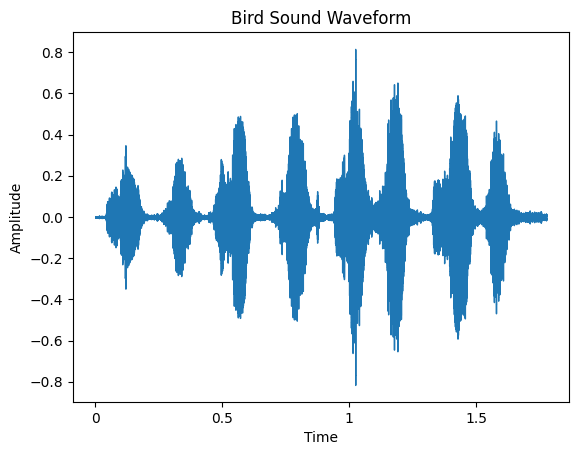

In [20]:
#визуализация амплитуд
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=1, sharex=True)
librosa.display.waveshow(original_audio, ax=ax, sr=sample_rate)
ax.set(title='Bird Sound Waveform', xlabel='Time', ylabel='Amplitude')

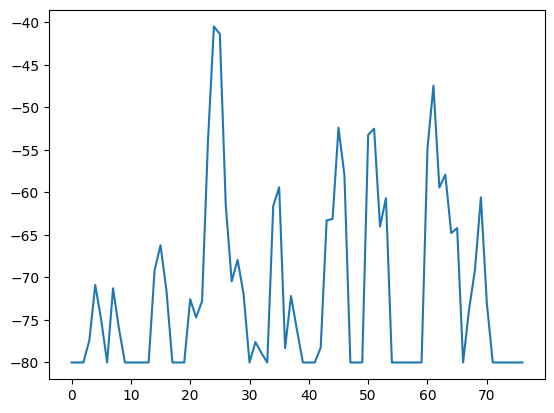

In [21]:
#кратковременное преобразование в Фурье и новый график
D = librosa.amplitude_to_db(np.abs(librosa.stft(original_audio)), ref=np.max) #для лучшего масштабирования переводим амплитуду в Дб
D.shape
plt.plot(D[1024])

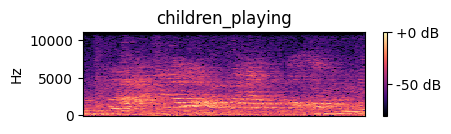

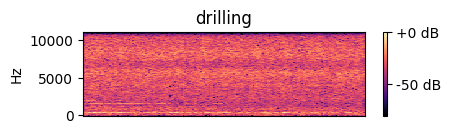

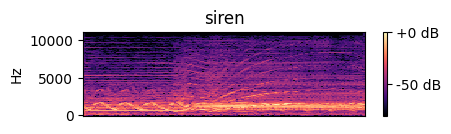

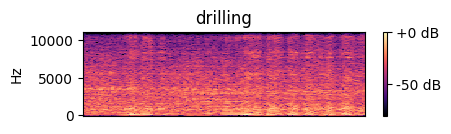

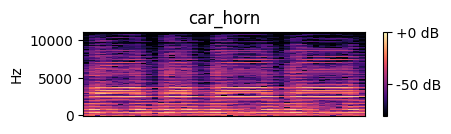

In [22]:
#наглядное построение нескольких спектрограмм
fold = np.array(audiofiles['fold'])
rng = np.random.default_rng()
sample = rng.integers(0, audiofiles.shape[0], size=5)

for i in sample:
    path = r'New_dataset/fold' + str(fold[i]) + '/' + str(arr[i])

    data, sampling_rate = librosa.load(path)
    plt.figure(figsize=(10, 5))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(data)), ref=np.max)
    plt.subplot(4, 2, 1)
    librosa.display.specshow(D, y_axis='linear')
    plt.colorbar(format='%+2.0f dB')
    plt.title(cls[i])


(128, 77)
bird


[Text(0.5, 1.0, 'Mel-frequency spectrogram')]

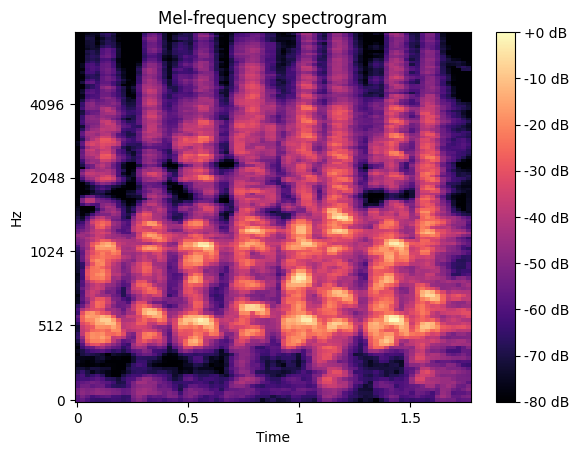

In [23]:
#преобразуем частоты в более близкие для человеческого слуха
path = r'New_dataset/fold' + str(fold[idx]) + '/' + str(arr[idx])
data, sampling_rate = librosa.load(path)
melspec = librosa.feature.melspectrogram(y=data, sr=sample_rate)
print(melspec.shape)
print(cls[idx])

Audio(data=data, rate=sample_rate)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
S_dB = librosa.power_to_db(melspec, ref=np.max)
img = librosa.display.specshow(S_dB, x_axis='time', 
                               y_axis='mel', sr=sampling_rate, fmax=8000, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency spectrogram')

In [25]:
feature = [] #разделение на признаки и метки
label = []

for i in range(len(audiofiles)):
    file_name = r'New_dataset/fold' + str(audiofiles['fold'][i]) + '/' + str(audiofiles['slice_file_name'][i])
    X, sampling_rate = librosa.load(file_name, res_type='kaiser_fast')
    mels = np.mean(librosa.feature.melspectrogram(y=X, sr=sampling_rate).T, axis=0)
    feature.append(mels)
    label.append(audiofiles['classID'][i])

In [26]:
#создание набора данных для обучения
temp = np.array([feature, label], dtype='object')
data = temp.transpose()

In [27]:
X_ = data[:,0] #функции
Y = data[:,1]
print(feature[0].shape)
print(X_.shape, Y.shape)

(128,)
(9532,) (9532,)


In [28]:
X = np.empty([9532, 128]) #пустой массив для обучения

for i in range(9532):
    X[i] = (X_[i])

In [29]:
import numpy as np
from tensorflow.keras import utils

def safe_to_categorical(X, Y):
    """Безопасное преобразование в one-hot с обработкой NaN и нечисловых данных"""
    
    # 1.проверяем тип данных
    if not np.issubdtype(Y.dtype, np.number):
        try:
            Y = Y.astype(float)  #пробуем преобразовать в float
        except ValueError:
            #если данные содержат строки, преобразуем в категории
            unique = np.unique(Y)
            mapping = {val: i for i, val in enumerate(unique)}
            Y = np.array([mapping[x] for x in Y])
    
    # 2.обработка NaN (float)
    if np.issubdtype(Y.dtype, np.floating):
        valid_mask = ~np.isnan(Y)
        Y = Y[valid_mask].astype(int)
        X_clean = X[valid_mask]
    
    # 3.определяем количество классов
    classes = np.unique(Y)
    num_classes = len(classes)
    
    # 4.one-hot кодирование
    Y_onehot = utils.to_categorical(Y, num_classes=num_classes)
    
    return X_clean, Y_onehot


#преобразование
X, Y_onehot = safe_to_categorical(X, Y)

#проверка результата
print("\nПосле преобразования:")
print(f"Новые размерности: X {X.shape}, Y {Y_onehot.shape}")
print("Пример one-hot представления (первые 5 строк):")
print(Y_onehot[:5])
print("Убедимся, что в каждой строке ровно одна 1:")
print("Суммы по строкам:", np.sum(Y_onehot, axis=1)[:10])  # Должно быть все 1.0


После преобразования:
Новые размерности: X (9532, 128), Y (9532, 11)
Пример one-hot представления (первые 5 строк):
[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]
Убедимся, что в каждой строке ровно одна 1:
Суммы по строкам: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [30]:
print(X.shape, Y_onehot.shape)

(9532, 128) (9532, 11)


In [31]:
#разделяем на обучающие и тестовые данные
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_onehot, test_size=0.2, random_state=123)

print('Train samples:', X_train.shape[0])
print('Test samples:', X_test.shape[0])

Train samples: 7625
Test samples: 1907


In [32]:
#создание сверточной нейронной сети
model = models.Sequential(
    [
        layers.Dense(1000,activation='relu', input_shape=(128,)),
        layers.Dense(750,activation='relu'),
        layers.Dense(500,activation='relu'),
        layers.Dense(100,activation='relu'),
        layers.Dense(50,activation='relu'),
        layers.Dense(11,activation='softmax'),
    ]
)

model.summary()

C:\Users\1\PycharmProjects\fastapi\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │       129,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 750)            │       750,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 500)            │       375,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │           561 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,310,961 (5.00 MB)

 Trainable params: 1,310,961 (5.00 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, Y_train, epochs=90, batch_size=50, validation_data=[X_test, Y_test])

Epoch 1/90
153/153 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.2418 - loss: 2.5966 - val_accuracy: 0.3728 - val_loss: 2.0369
Epoch 2/90
153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.3851 - loss: 2.0041 - val_accuracy: 0.4305 - val_loss: 1.7788
Epoch 3/90
153/153 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.4780 - loss: 1.6603 - val_accuracy: 0.5422 - val_loss: 1.5325
Epoch 4/90
153/153 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.5726 - loss: 1.3924 - val_accuracy: 0.6057 - val_loss: 1.2974
Epoch 5/90
153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.6350 - loss: 1.1479 - val_accuracy: 0.6256 - val_loss: 1.2453
Epoch 6/90
153/153 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.6976 - loss: 0.9822 - val_accuracy: 0.6644 - val_loss: 1.1094
Epoch 7/90
153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.7190 - loss: 0.8684 - val_accuracy: 0.6938 - val_loss: 1.0279
Epoch 8/90
153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7414 - loss: 0.8269 - val_acc

In [34]:
classes = audiofiles.groupby('classID')['class'].unique()
classes

classID
0.0      [air_conditioner]
1.0                 [bird]
2.0             [car_horn]
3.0     [children_playing]
4.0             [dog_bark]
5.0             [drilling]
6.0        [engine_idling]
7.0             [gun_shot]
8.0           [jackhammer]
9.0                [siren]
10.0        [street_music]
Name: class, dtype: object

In [35]:
def prediction_parser(file_name, model):
    feature = []
    label = []
    audiodata, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
    
    mels = np.mean(librosa.feature.melspectrogram(y=audiodata, sr=sample_rate).T, axis=0)
    feature.append(mels)
    label.append(audiofiles['class'][audiofiles['slice_file_name']==file_name.split('/', 5)[5]].values)
    temp_preds = np.array([feature, label], dtype=object)
    date_preds = temp_preds.transpose()
    X_ = date_preds[:, 0]
    X = np.empty([1, 128])
    X[0] = (X_[0])
    Audio(data=original_audio, rate=sample_rate)
    classid = np.argmax(model.predict(X))
    print('Class predicted:', classes[classid][0], '\n\n', 'actual', label)
    return Audio(data=audiodata, rate=sample_rate)

In [36]:
prediction_parser('C:/Users/1/PycharmProjects/fastapi/New_dataset/fold1/193698-2-0-64.wav', model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Class predicted: children_playing 

 actual [array([], dtype=object)]


In [37]:
print(audiofiles['slice_file_name'][idx])
audiofiles['fold'][idx]

SpaceJoe_510941.wav


np.int64(1)

In [38]:
prediction_parser('C:/Users/1/PycharmProjects/fastapi/New_dataset/fold1/SpaceJoe_510941.wav', model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
Class predicted: bird 

 actual [array([], dtype=object)]
